Found 2 scenes
Using: S2B_MSIL2A_20240621T182919_R027_T11SLT_20240622T012025, cloud cover: 0.059413%
NDVI range: -1.00 to 1.00
NDVI mean: 0.10


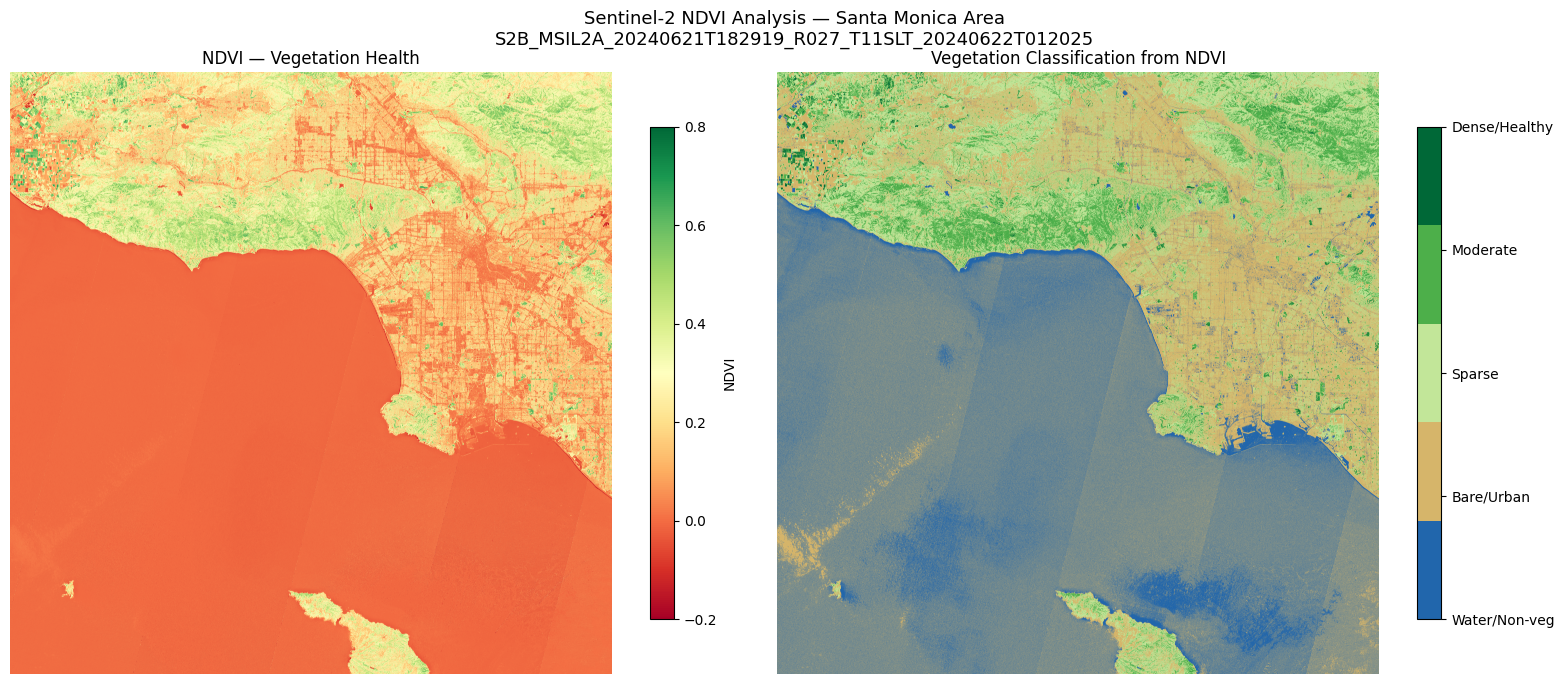

In [1]:
import pystac_client
import planetary_computer
import rioxarray
import matplotlib.pyplot as plt
import numpy as np

# 1. Search for a scene
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=[-118.52, 33.97, -118.43, 34.03],  # Santa Monica area
    datetime="2024-06-01/2024-06-30",
    query={"eo:cloud_cover": {"lt": 20}}
)

items = search.item_collection()
print(f"Found {len(items)} scenes")

# Pick the least cloudy scene
item = min(items, key=lambda x: x.properties["eo:cloud_cover"])
print(f"Using: {item.id}, cloud cover: {item.properties['eo:cloud_cover']}%")

# 2. Load the Red (B04) and NIR (B08) bands
red = rioxarray.open_rasterio(item.assets["B04"].href).squeeze()
nir = rioxarray.open_rasterio(item.assets["B08"].href).squeeze()

# 3. Calculate NDVI
# Convert to float to avoid integer division issues
red_f = red.astype(float)
nir_f = nir.astype(float)

ndvi = (nir_f - red_f) / (nir_f + red_f)

# Handle division by zero (where both bands are 0, e.g. nodata areas)
ndvi = ndvi.where(np.isfinite(ndvi), 0)

print(f"NDVI range: {float(ndvi.min()):.2f} to {float(ndvi.max()):.2f}")
print(f"NDVI mean: {float(ndvi.mean()):.2f}")

# 4. Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: NDVI heatmap
im = axes[0].imshow(
    ndvi.values,
    cmap="RdYlGn",  # red = low/no vegetation, green = healthy vegetation
    vmin=-0.2,
    vmax=0.8
)
axes[0].set_title("NDVI — Vegetation Health")
plt.colorbar(im, ax=axes[0], label="NDVI", shrink=0.8)

# Right: Classified vegetation map
# Threshold NDVI into categories
veg_classes = np.zeros_like(ndvi.values)
veg_classes[ndvi.values < 0.0] = 0   # Water / non-vegetated
veg_classes[(ndvi.values >= 0.0) & (ndvi.values < 0.2)] = 1   # Bare soil / urban
veg_classes[(ndvi.values >= 0.2) & (ndvi.values < 0.4)] = 2   # Sparse vegetation
veg_classes[(ndvi.values >= 0.4) & (ndvi.values < 0.6)] = 3   # Moderate vegetation
veg_classes[ndvi.values >= 0.6] = 4   # Dense / healthy vegetation

from matplotlib.colors import ListedColormap
colors = ["#2166ac", "#d6b56a", "#c2e699", "#4daf4a", "#006837"]
labels = ["Water/Non-veg", "Bare/Urban", "Sparse", "Moderate", "Dense/Healthy"]
cmap = ListedColormap(colors)

im2 = axes[1].imshow(veg_classes, cmap=cmap, vmin=0, vmax=4)
axes[1].set_title("Vegetation Classification from NDVI")
cbar = plt.colorbar(im2, ax=axes[1], ticks=[0, 1, 2, 3, 4], shrink=0.8)
cbar.ax.set_yticklabels(labels)

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Sentinel-2 NDVI Analysis — Santa Monica Area\n{item.id}", fontsize=13)
plt.tight_layout()
plt.savefig("ndvi_analysis.png", dpi=150)
plt.show()

Found 45 scenes
Using: S2B_MSIL2A_20240627T184919_R113_T11SKA_20240628T001652, cloud cover: 0.0%
NDVI range: 0.00 to 0.63
NDVI mean: 0.00


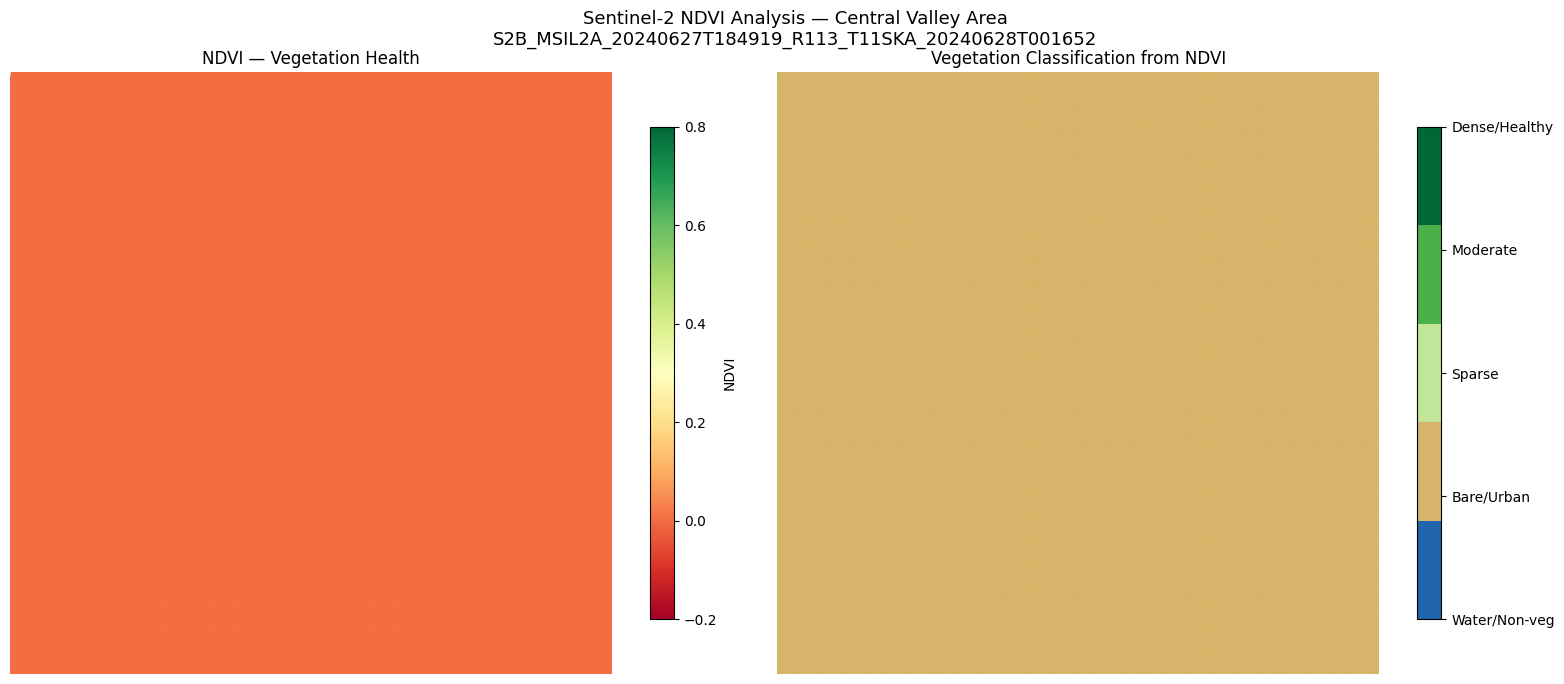

In [2]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=[-120.5, 36.5, -120.0, 37.0],  # Central Valley area
    datetime="2024-06-01/2024-06-30",
    query={"eo:cloud_cover": {"lt": 20}}
)

items = search.item_collection()
print(f"Found {len(items)} scenes")

# Pick the least cloudy scene
item = min(items, key=lambda x: x.properties["eo:cloud_cover"])
print(f"Using: {item.id}, cloud cover: {item.properties['eo:cloud_cover']}%")

# 2. Load the Red (B04) and NIR (B08) bands
red = rioxarray.open_rasterio(item.assets["B04"].href).squeeze()
nir = rioxarray.open_rasterio(item.assets["B08"].href).squeeze()

# 3. Calculate NDVI
# Convert to float to avoid integer division issues
red_f = red.astype(float)
nir_f = nir.astype(float)

ndvi = (nir_f - red_f) / (nir_f + red_f)

# Handle division by zero (where both bands are 0, e.g. nodata areas)
ndvi = ndvi.where(np.isfinite(ndvi), 0)

print(f"NDVI range: {float(ndvi.min()):.2f} to {float(ndvi.max()):.2f}")
print(f"NDVI mean: {float(ndvi.mean()):.2f}")

# 4. Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: NDVI heatmap
im = axes[0].imshow(
    ndvi.values,
    cmap="RdYlGn",  # red = low/no vegetation, green = healthy vegetation
    vmin=-0.2,
    vmax=0.8
)
axes[0].set_title("NDVI — Vegetation Health")
plt.colorbar(im, ax=axes[0], label="NDVI", shrink=0.8)

# Right: Classified vegetation map
# Threshold NDVI into categories
veg_classes = np.zeros_like(ndvi.values)
veg_classes[ndvi.values < 0.0] = 0   # Water / non-vegetated
veg_classes[(ndvi.values >= 0.0) & (ndvi.values < 0.2)] = 1   # Bare soil / urban
veg_classes[(ndvi.values >= 0.2) & (ndvi.values < 0.4)] = 2   # Sparse vegetation
veg_classes[(ndvi.values >= 0.4) & (ndvi.values < 0.6)] = 3   # Moderate vegetation
veg_classes[ndvi.values >= 0.6] = 4   # Dense / healthy vegetation

from matplotlib.colors import ListedColormap
colors = ["#2166ac", "#d6b56a", "#c2e699", "#4daf4a", "#006837"]
labels = ["Water/Non-veg", "Bare/Urban", "Sparse", "Moderate", "Dense/Healthy"]
cmap = ListedColormap(colors)

im2 = axes[1].imshow(veg_classes, cmap=cmap, vmin=0, vmax=4)
axes[1].set_title("Vegetation Classification from NDVI")
cbar = plt.colorbar(im2, ax=axes[1], ticks=[0, 1, 2, 3, 4], shrink=0.8)
cbar.ax.set_yticklabels(labels)

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Sentinel-2 NDVI Analysis — Central Valley Area\n{item.id}", fontsize=13)
plt.tight_layout()
plt.savefig("ndvi_analysis.png", dpi=150)
plt.show()